## 1. Setup

In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

## 2. Imports

In [2]:
from loading import load_data
from src.fault_ticket.pipeline import clean_data
from src.fault_ticket.metrics import calculate_zone_summary

## 3. Load Raw Data

In [3]:
df_raw = load_data('data/raw/fault_tickets/national_dataset.csv')
print(f"📊 Raw Data: {len(df_raw):,} rows, {len(df_raw.columns)} columns")

📊 Raw Data: 166,998 rows, 98 columns


## 4. Clean Data

In [4]:
os.makedirs('output', exist_ok=True)
df = clean_data(df_raw, "Region 3", save_output=True)
print(f"✅ Cleaned: {len(df):,} rows · {len(df.columns)} columns")

INFO:pipeline:Pre-clean quality: 166,998 rows | score=58.5 | dupes=30144 | blank_priority=381
INFO:pipeline:Saved 1000 rows → snapshot_pre_cleaning.csv
INFO:pipeline:
────────────────────────────────────────────────────────────
  PHASE 1 – STRUCTURAL FILTERING
────────────────────────────────────────────────────────────
INFO:pipeline:Step 1 – drop duplicate TICKETID: dropped 30,144 rows (remaining: 136,854)
INFO:pipeline:Step 2 – drop blank Priority: dropped 363 rows (remaining: 136,491)
INFO:pipeline:Step 3 – keep Priority 1-3: dropped 74,934 rows (remaining: 61,557)
INFO:pipeline:Step 4 – valid Urgency: dropped 0 rows (remaining: 61,557)
INFO:pipeline:Step 5 – valid FT Status: dropped 7,808 rows (remaining: 53,749)
INFO:pipeline:Step 6 – drop Fault Type INVALID: dropped 604 rows (remaining: 53,145)
INFO:pipeline:Saved 1000 rows → snapshot_after_phase1.csv
INFO:pipeline:
────────────────────────────────────────────────────────────
  PHASE 2 – DATA REPAIR & FIELD RECONSTRUCTION
───────

✅ Cleaned: 38,319 rows · 29 columns


## 5. Compute Zone Summary

In [5]:
# exclude_unknown=True (default) — Unknown zone excluded from all aggregations
summary = calculate_zone_summary(df)
summary

,ZONE,Ticket_Count,MTTR,SLA_Compliance_Rate,Total_Faults,Unique_Sites,Fault_Density,Avg_NOC_Time,Avg_Field_Time
4,ZONE 5,9131,77.750298,79.586026,9131,1059,8.622285,0.081680,80.709198
3,ZONE 4,7952,47.442871,84.544769,7952,1040,7.646154,6.727763,42.595963
1,ZONE 2,7307,50.968636,83.864787,7307,1043,7.005753,0.099231,52.392040
2,ZONE 3,4393,32.315742,80.582745,4393,666,6.596096,0.113962,33.300514
0,ZONE 1,4306,62.582626,83.070135,4306,456,9.442982,15.847999,49.649857
5,ZONE 6,3818,70.033180,80.853850,3818,477,8.004193,0.071990,71.822372


## 6. NCR Overview Statistics

In [6]:
print("="*80)
print("NCR (REGION 3) BASELINE OVERVIEW")
print("="*80)

clean_ts = df[df['Timestamp_Integrity']] if 'Timestamp_Integrity' in df.columns else df

print(f"\n📊 Dataset Overview:")
print(f"  • Total Tickets   : {len(df):,}")
print(f"  • Unique Sites    : {df['Area'].nunique():,}")
print(f"  • Date Range      : {df['REPORTDATE'].min()} to {df['REPORTDATE'].max()}")
print(f"  • Data Completeness: Region 3 only (complete ROC + Field tickets)")

print(f"\n🎯 Performance Metrics:")
print(f"  • SLA Compliance             : {df['SLA_Compliant'].mean()*100:.1f}%")
print(f"  • Average MTTR               : {df['OUTAGEDURATION'].mean():.1f} hours")
print(f"  • Average NOC Time           : {clean_ts['DISPATCH_DELAY_HOURS'].mean():.1f} hours  (timestamp-clean tickets only)")
print(f"  • Average Field Engineer Time: {clean_ts['FIELD_TIME_HOURS'].mean():.1f} hours  (timestamp-clean tickets only)")
print(f"  • Fault Density              : {len(df)/df['Area'].nunique():.1f} faults per site")

print(f"\n📋 Priority Distribution:")
for p, count in df['Priority'].value_counts().sort_index().items():
    print(f"  • Priority {p}: {count:,} ({count/len(df)*100:.1f}%)")

NCR (REGION 3) BASELINE OVERVIEW

📊 Dataset Overview:
  • Total Tickets   : 38,319
  • Unique Sites    : 4,803
  • Date Range      : 2022-01-01 00:18:27 to 2023-05-11 11:13:03
  • Data Completeness: Region 3 only (complete ROC + Field tickets)

🎯 Performance Metrics:
  • SLA Compliance             : 82.2%
  • Average MTTR               : 61.4 hours
  • Average NOC Time           : 6.2 hours  (timestamp-clean tickets only)
  • Average Field Engineer Time: 57.5 hours  (timestamp-clean tickets only)
  • Fault Density              : 8.0 faults per site

📋 Priority Distribution:
  • Priority 1: 167 (0.4%)
  • Priority 2: 4,538 (11.8%)
  • Priority 3: 33,614 (87.7%)


## 7. Timestamp Integrity Check

In [7]:
# ── What is Timestamp_Integrity? ─────────────────────────────────────────────
# Pipeline Step 20 flags tickets where DISPATCHDATE was recorded AFTER
# RESOLVEDDATE (i.e. FIELD_TIME_HOURS < 0) or where DISPATCH_DELAY_HOURS
# exceeds total OUTAGEDURATION. Both conditions indicate a data entry error
# in the source system — typically a field engineer logging the dispatch
# action after the ticket was already closed.
#
# These tickets are RETAINED in the dataset (they count in volume and SLA
# metrics) but EXCLUDED from NOC time and field time aggregations in
# calculate_noc_time() and calculate_field_time().
# ─────────────────────────────────────────────────────────────────────────────

if 'Timestamp_Integrity' not in df.columns:
    print("⚠️  Timestamp_Integrity column not found.")
    print("   Re-run the pipeline with the updated pipeline.py to generate it.")
else:
    total    = len(df)
    bad      = (~df['Timestamp_Integrity']).sum()
    clean    = total - bad

    print("=" * 70)
    print("TIMESTAMP INTEGRITY REPORT")
    print("=" * 70)
    print(f"  Total tickets             : {total:,}")
    print(f"  Timestamp-clean tickets   : {clean:,}  ({clean/total*100:.1f}%)")
    print(f"  Corrupt timestamps flagged: {bad:,}  ({bad/total*100:.1f}%)")

    print(f"\n  Corruption defined as:")
    print(f"    • FIELD_TIME_HOURS < 0     (DISPATCHDATE after RESOLVEDDATE)")
    print(f"    • DISPATCH_DELAY_HOURS > OUTAGEDURATION  (NOC time > total MTTR)")

    print(f"\n  Likely root cause:")
    print(f"    Field engineers logging dispatch actions after ticket closure")
    print(f"    in the source system — a known data entry pattern.")

    print(f"\nBreakdown by zone:")
    zone_bad = (df.groupby('ZONE')
                  .apply(lambda x: pd.Series({
                      'Total'  : len(x),
                      'Corrupt': (~x['Timestamp_Integrity']).sum(),
                      'Pct'    : f"{(~x['Timestamp_Integrity']).sum()/len(x)*100:.1f}%",
                      'Avg_DISPATCH_corrupt':
                          x.loc[~x['Timestamp_Integrity'],'DISPATCH_DELAY_HOURS'].mean()
                          if (~x['Timestamp_Integrity']).sum() > 0 else 0
                  }), include_groups=False)
                  .sort_values('Corrupt', ascending=False))
    print(zone_bad.to_string())

    print(f"\n  Impact of exclusion on NOC/Field averages:")
    for zone in ['ZONE 1','ZONE 2','ZONE 3','ZONE 4','ZONE 5','ZONE 6']:
        zdf  = df[df['ZONE']==zone]
        zclean = zdf[zdf['Timestamp_Integrity']]
        if len(zdf) == 0: continue
        n_bad = (~zdf['Timestamp_Integrity']).sum()
        if n_bad == 0: continue
        print(f"  {zone}: {n_bad} corrupt tickets removed  |  "
              f"NOC {zdf['DISPATCH_DELAY_HOURS'].mean():.1f}h → {zclean['DISPATCH_DELAY_HOURS'].mean():.1f}h  |  "
              f"Field {zdf['FIELD_TIME_HOURS'].mean():.1f}h → {zclean['FIELD_TIME_HOURS'].mean():.1f}h")

TIMESTAMP INTEGRITY REPORT
  Total tickets             : 38,319
  Timestamp-clean tickets   : 36,854  (96.2%)
  Corrupt timestamps flagged: 1,465  (3.8%)

  Corruption defined as:
    • FIELD_TIME_HOURS < 0     (DISPATCHDATE after RESOLVEDDATE)
    • DISPATCH_DELAY_HOURS > OUTAGEDURATION  (NOC time > total MTTR)

  Likely root cause:
    Field engineers logging dispatch actions after ticket closure
    in the source system — a known data entry pattern.

Breakdown by zone:
         Total  Corrupt   Pct  Avg_DISPATCH_corrupt
ZONE                                               
ZONE 5    9131      349  3.8%            475.073656
ZONE 4    7952      311  3.9%            863.977571
ZONE 2    7307      215  2.9%             81.593261
ZONE 1    4306      193  4.5%           1528.955989
ZONE 3    4393      145  3.3%              1.780425
Unknown   1412      138  9.8%           2058.488160
ZONE 6    3818      114  3.0%            232.965470

  Impact of exclusion on NOC/Field averages:
  ZONE 1:

## 8. Quick Visual Checks

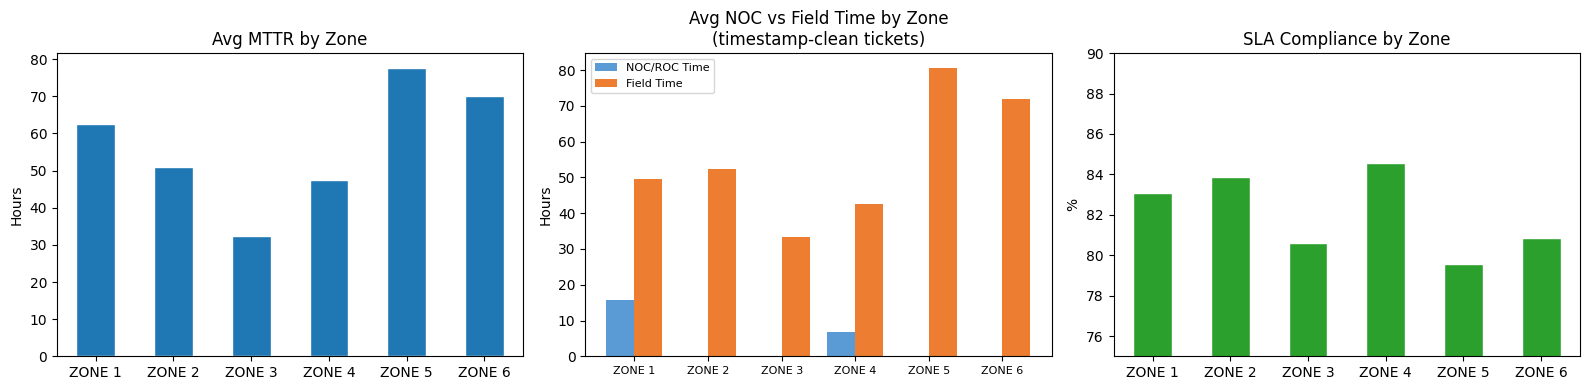

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# MTTR by zone
df.groupby('ZONE')['OUTAGEDURATION'].mean().reindex(
    [f'ZONE {i}' for i in range(1,7)]).plot(
    kind='bar', ax=axes[0], color='#1f77b4', edgecolor='white')
axes[0].set_title('Avg MTTR by Zone')
axes[0].set_ylabel('Hours')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# NOC vs Field time (clean tickets only)
if 'Timestamp_Integrity' in df.columns:
    clean_df = df[df['Timestamp_Integrity']]
else:
    clean_df = df

import numpy as np
zones = [f'ZONE {i}' for i in range(1,7)]
noc_vals   = clean_df.groupby('ZONE')['DISPATCH_DELAY_HOURS'].mean().reindex(zones)
field_vals = clean_df.groupby('ZONE')['FIELD_TIME_HOURS'].mean().reindex(zones)
x = np.arange(len(zones)); w = 0.38
axes[1].bar(x-w/2, noc_vals,   w, label='NOC/ROC Time',   color='#5b9bd5')
axes[1].bar(x+w/2, field_vals, w, label='Field Time',     color='#ed7d31')
axes[1].set_xticks(x)
axes[1].set_xticklabels(zones, rotation=0, fontsize=8)
axes[1].set_title('Avg NOC vs Field Time by Zone\n(timestamp-clean tickets)')
axes[1].set_ylabel('Hours')
axes[1].legend(fontsize=8)

# SLA compliance
df.groupby('ZONE')['SLA_Compliant'].mean().mul(100).reindex(zones).plot(
    kind='bar', ax=axes[2], color='#2ca02c', edgecolor='white')
axes[2].set_title('SLA Compliance by Zone')
axes[2].set_ylabel('%')
axes[2].set_xlabel('')
axes[2].set_ylim(75, 90)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('reports/figures/project1_ncr/02_quick_checks.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Summary for Next Notebooks

In [9]:
summary.to_csv('output/ncr_summary.csv', index=False)
print("✅ Saved: output/ncr_summary.csv")

✅ Saved: output/ncr_summary.csv
